# MLP Genomic Model: Evaluation & Predictions with Confusion Matrix

This notebook provides comprehensive evaluation of the trained MLP genomic model, generates confusion matrices, and demonstrates prediction on unknown datasets.

## Section 1: Setup and Load Training Results

In [30]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Add project path
project_dir = os.path.abspath('.')
sys.path.insert(0, project_dir)

from model.model_MLPGenomic import MLPGenomics
from utils.prediction_utils import load_model, predict_batch, predict_with_ensemble
from dataset.SurvivalGenomicDataset import SurvivalGenomicDataset

print("✓ All imports successful!")
print(f"Working directory: {project_dir}")

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

✓ All imports successful!
Working directory: /home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival
Device: cpu


In [31]:
# Load training history across all folds
result_dir = os.path.join(project_dir, "result")
histories = {}
fold_summaries = []

for fold_idx in range(5):
    history_path = os.path.join(result_dir, f"training_history_fold_{fold_idx}.csv")
    if os.path.exists(history_path):
        histories[fold_idx] = pd.read_csv(history_path)
        print(f"✓ Loaded training history for fold {fold_idx}")

# Load best metrics summary
summary_path = os.path.join(result_dir, "training_best_by_fold.csv")
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
    print(f"\n✓ Loaded per-fold best metrics:")
    print(summary_df)
else:
    print("⚠ Summary file not found. Please train the model first.")
    summary_df = None

✓ Loaded training history for fold 0
✓ Loaded training history for fold 1
✓ Loaded training history for fold 2
✓ Loaded training history for fold 3
✓ Loaded training history for fold 4

✓ Loaded per-fold best metrics:
   fold  best_train_acc  best_train_acc_epoch  best_val_acc  \
0     0        0.640553                    10      0.267857   
1     1        0.584906                     9      0.278689   
2     2        0.687783                     9      0.326923   
3     3        0.609091                     8      0.339623   
4     4        0.666667                     9      0.313725   

   best_val_acc_epoch  best_train_loss  best_train_loss_epoch  best_val_loss  \
0                   6         1.156810                     10       1.603046   
1                   7         1.235187                      9       1.779978   
2                   5         1.163317                      9       1.554325   
3                   8         1.214448                     10       1.567567   
4  

## Section 2: Training History Visualization

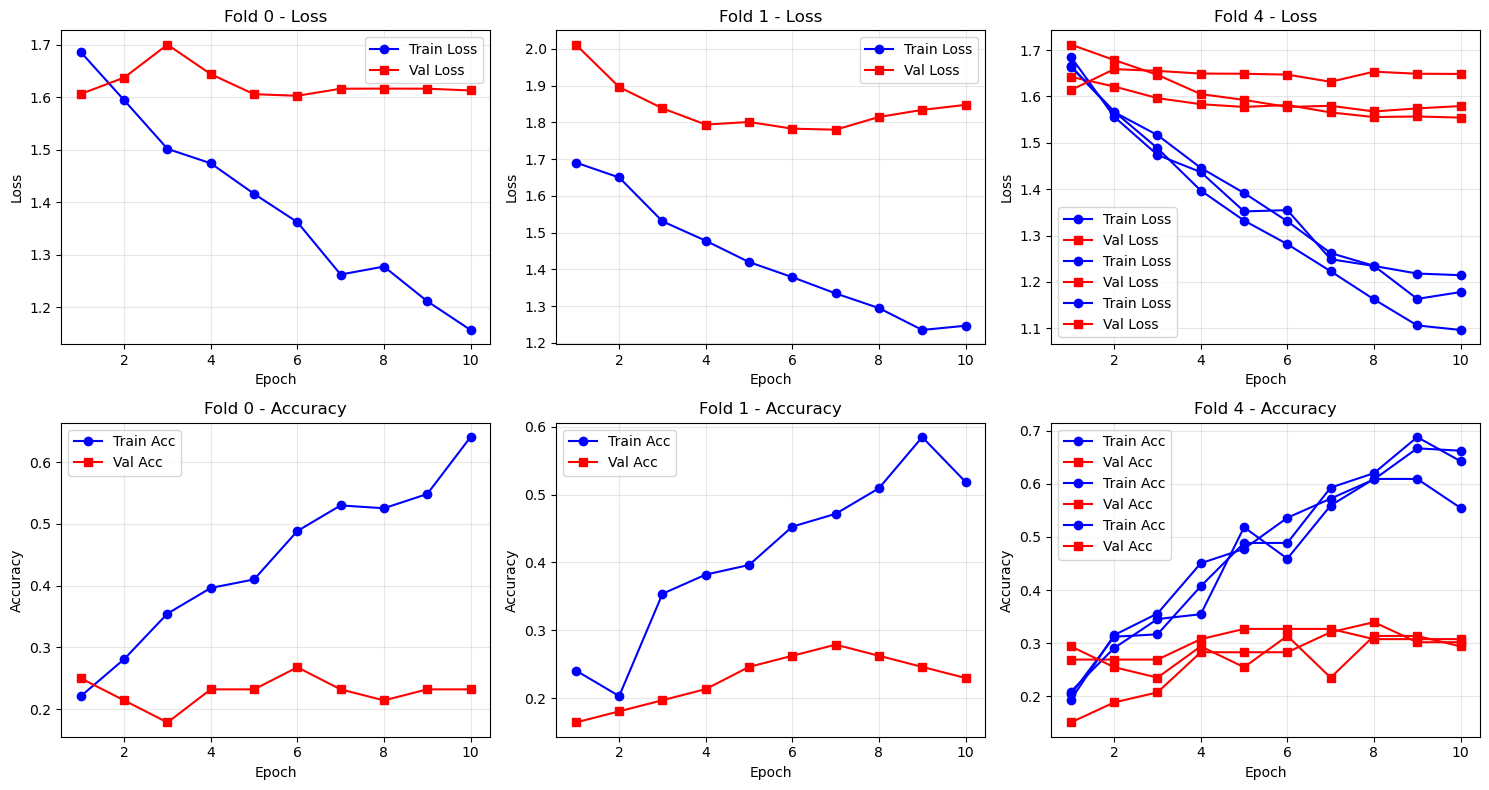

✓ Training history plots saved!

TRAINING SUMMARY STATISTICS (5-Fold Cross-Validation)
Average Best Val Accuracy: 0.3054 ± 0.0309
Average Best Val Loss: 1.6237 ± 0.0907
Average Best Train Accuracy: 0.6378 ± 0.0417
Average Best Train Loss: 1.1732 ± 0.0544


In [32]:
if histories:
    # Plot training curves for all folds
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    for fold_idx, history_df in histories.items():
        ax_loss = axes[0, fold_idx] if fold_idx < 3 else axes[0, 2]
        ax_acc = axes[1, fold_idx] if fold_idx < 3 else axes[1, 2]
        
        # Loss plot
        ax_loss.plot(history_df['epoch'], history_df['train_loss'], 'b-', label='Train Loss', marker='o')
        ax_loss.plot(history_df['epoch'], history_df['val_loss'], 'r-', label='Val Loss', marker='s')
        ax_loss.set_title(f'Fold {fold_idx} - Loss')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)
        
        # Accuracy plot
        ax_acc.plot(history_df['epoch'], history_df['train_acc'], 'b-', label='Train Acc', marker='o')
        ax_acc.plot(history_df['epoch'], history_df['val_acc'], 'r-', label='Val Acc', marker='s')
        ax_acc.set_title(f'Fold {fold_idx} - Accuracy')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, 'training_history_all_folds.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Training history plots saved!")

# Summary statistics
if summary_df is not None:
    print("\n" + "="*60)
    print("TRAINING SUMMARY STATISTICS (5-Fold Cross-Validation)")
    print("="*60)
    print(f"Average Best Val Accuracy: {summary_df['best_val_acc'].mean():.4f} ± {summary_df['best_val_acc'].std():.4f}")
    print(f"Average Best Val Loss: {summary_df['best_val_loss'].mean():.4f} ± {summary_df['best_val_loss'].std():.4f}")
    print(f"Average Best Train Accuracy: {summary_df['best_train_acc'].mean():.4f} ± {summary_df['best_train_acc'].std():.4f}")
    print(f"Average Best Train Loss: {summary_df['best_train_loss'].mean():.4f} ± {summary_df['best_train_loss'].std():.4f}")
    print("="*60)

## Section 3: Load Test Data and Generate Predictions for All Folds

In [18]:
# Load merged test data from training
merge_df_path = os.path.join(result_dir, "merge_df.csv")
test_split_path = os.path.join(result_dir, "test_merged_split.csv")

if os.path.exists(test_split_path):
    test_df = pd.read_csv(test_split_path)
    print(f"✓ Loaded test data: {test_df.shape}")
    print(test_df.head())
    
    # Identify feature columns (all except label and metadata)
    feature_cols = [col for col in test_df.columns if col not in ['__label', '__row_index', '_PATIENT', 'CDE_survival_time', 'CDE_survival_time_bin']]
    print(f"\nNumber of features: {len(feature_cols)}")
    
    # Extract test features and labels
    test_features = test_df[feature_cols].values.astype(np.float32)
    test_labels = test_df['__label'].values
    
    print(f"Test features shape: {test_features.shape}")
    print(f"Test labels shape: {test_labels.shape}")
    print(f"Unique labels in test set: {np.unique(test_labels)}")
else:
    print("⚠ Test data not found. Running training first...")
    test_features = None
    test_labels = None

✓ Loaded test data: (51, 4376)
       _PATIENT  __label  __row_index  CDE_survival_time  \
0  TCGA-02-2470        2           89              393.0   
1  TCGA-06-0145        0          109               71.0   
2  TCGA-06-0152        2          114              375.0   
3  TCGA-06-0157        0          119               97.0   
4  TCGA-06-0168        3          124              598.0   

   CDE_survival_time_bin  A2M  AAAS  AADAT  AARS1  ABAT  ...  ZNF292  ZNF365  \
0                      2  452     7      2     19    14  ...       5       6   
1                      0  513    10      2     21    23  ...       6       1   
2                      2  393    25      5     39    50  ...       8       3   
3                      0  409    27      8     50    95  ...       8       2   
4                      3  152     9      2     17    16  ...       1       3   

   ZNF639  ZNF707  ZNFX1  ZNRF4  ZPBP  ZW10  ZWINT  ZYX  
0       4       1     14      0     0     5      7   29  
1       6  

In [19]:
if test_features is not None:
    # Load all saved models
    model_dir = os.path.join(result_dir, "model_checkpoints")
    model_paths = []
    
    for fold_idx in range(5):
        model_path = os.path.join(model_dir, f"best_model_fold_{fold_idx}.pt")
        if os.path.exists(model_path):
            model_paths.append(model_path)
            print(f"✓ Found model for fold {fold_idx}")
    
    print(f"\n✓ Loaded {len(model_paths)} models out of 5 folds")
    
    if len(model_paths) > 0:
        # Generate ensemble predictions
        print("\nGenerating ensemble predictions...")
        ensemble_logits, ensemble_probs, ensemble_preds, confidences = predict_with_ensemble(
            model_paths, test_features, ensemble_type='mean', device=device
        )
        
        print(f"Ensemble predictions shape: {ensemble_preds.shape}")
        print(f"Ensemble probabilities shape: {ensemble_probs.shape}")
        print(f"Mean confidence: {confidences.mean():.4f}")
        print(f"Min confidence: {confidences.min():.4f}")
        print(f"Max confidence: {confidences.max():.4f}")
    else:
        print("⚠ No model checkpoints found. Please train the model first.")
        ensemble_preds = None

✓ Found model for fold 0
✓ Found model for fold 1
✓ Found model for fold 2
✓ Found model for fold 3
✓ Found model for fold 4

✓ Loaded 5 models out of 5 folds

Generating ensemble predictions...


RuntimeError: Error(s) in loading state_dict for MLPGenomics:
	Missing key(s) in state_dict: "net.0.weight", "net.0.bias", "net.1.weight", "net.1.bias", "net.1.running_mean", "net.1.running_var", "net.4.weight", "net.4.bias", "net.5.weight", "net.5.bias", "net.5.running_mean", "net.5.running_var", "to_logits.weight", "to_logits.bias". 
	Unexpected key(s) in state_dict: "cluster_centers", "encoder.0.weight", "encoder.0.bias", "encoder.1.weight", "encoder.1.bias", "encoder.1.running_mean", "encoder.1.running_var", "encoder.1.num_batches_tracked", "encoder.4.weight", "encoder.4.bias", "encoder.5.weight", "encoder.5.bias", "encoder.5.running_mean", "encoder.5.running_var", "encoder.5.num_batches_tracked", "cluster_norm.weight", "cluster_norm.bias", "classifier.0.weight", "classifier.0.bias", "classifier.3.weight", "classifier.3.bias". 

## Section 4: Generate Confusion Matrix and Classification Metrics

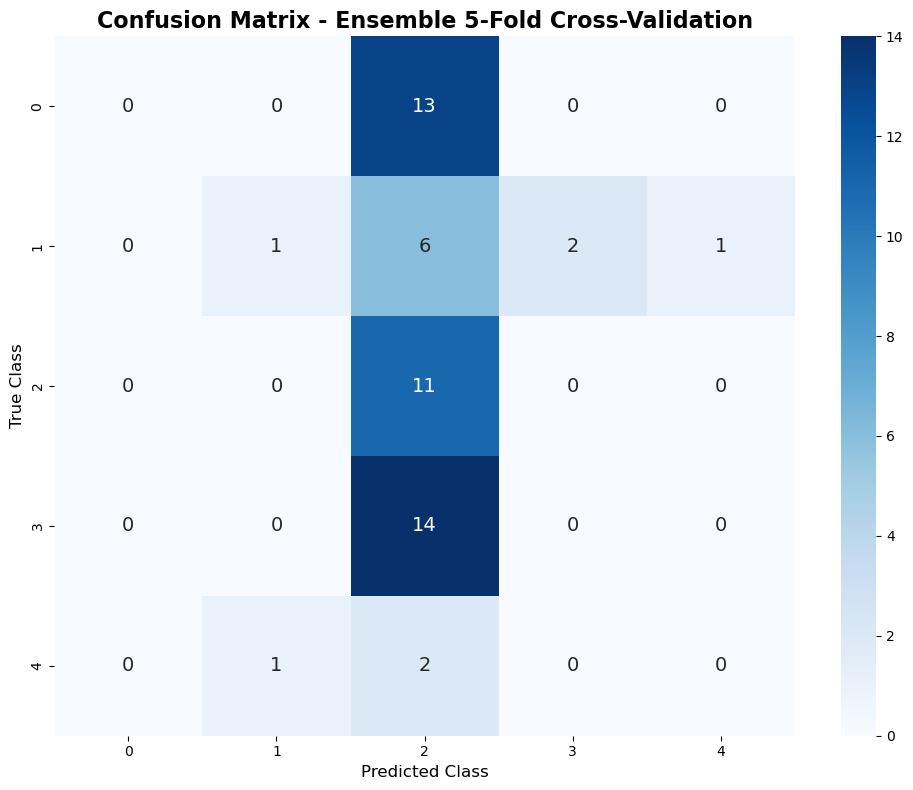

✓ Confusion matrix saved!

Confusion Matrix:
[[ 0  0 13  0  0]
 [ 0  1  6  2  1]
 [ 0  0 11  0  0]
 [ 0  0 14  0  0]
 [ 0  1  2  0  0]]

DETAILED CLASSIFICATION METRICS (5-Fold Ensemble)
Overall Accuracy: 0.2353

Per-Class Metrics:
----------------------------------------------------------------------
Class 0:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Support:   13

Class 1:
  Precision: 0.5000
  Recall:    0.1000
  F1-Score:  0.1667
  Support:   10

Class 2:
  Precision: 0.2391
  Recall:    1.0000
  F1-Score:  0.3860
  Support:   11

Class 3:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Support:   14

Class 4:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Support:   3

----------------------------------------------------------------------
Macro-averaged Precision: 0.1478
Macro-averaged Recall:    0.2200
Macro-averaged F1-Score:  0.1105

Sklearn Classification Report:
              precision    recall  f1-score   support

           

In [ ]:
if ensemble_preds is not None and test_labels is not None:
    # Compute confusion matrix
    cm = confusion_matrix(test_labels, ensemble_preds)
    
    # Compute classification metrics
    accuracy = accuracy_score(test_labels, ensemble_preds)
    precision, recall, f1, support = precision_recall_fscore_support(
        test_labels, ensemble_preds, average=None
    )
    
    # Visualize confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=range(cm.shape[0]), yticklabels=range(cm.shape[0]),
                annot_kws={'size': 14})
    plt.title('Confusion Matrix - Ensemble 5-Fold Cross-Validation', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Confusion matrix saved!")
    print(f"\nConfusion Matrix:\n{cm}\n")
    
    # Print detailed metrics
    print("="*70)
    print("DETAILED CLASSIFICATION METRICS (5-Fold Ensemble)")
    print("="*70)
    print(f"Overall Accuracy: {accuracy:.4f}\n")
    
    print("Per-Class Metrics:")
    print("-" * 70)
    for class_idx in range(len(precision)):
        print(f"Class {class_idx}:")
        print(f"  Precision: {precision[class_idx]:.4f}")
        print(f"  Recall:    {recall[class_idx]:.4f}")
        print(f"  F1-Score:  {f1[class_idx]:.4f}")
        print(f"  Support:   {int(support[class_idx])}")
        print()
    
    print("-" * 70)
    print(f"Macro-averaged Precision: {precision.mean():.4f}")
    print(f"Macro-averaged Recall:    {recall.mean():.4f}")
    print(f"Macro-averaged F1-Score:  {f1.mean():.4f}")
    print("="*70)
    
    # Classification report
    print("\nSklearn Classification Report:")
    print(classification_report(test_labels, ensemble_preds))

## Section 5: Prediction on Unknown Dataset

In [ ]:
# Define prediction function for unknown data
def predict_on_new_data(unknown_features, model_paths, feature_cols, scaler=None, ensemble_type='mean'):
    """
    Predict on new unknown data using ensemble of models.
    
    Args:
        unknown_features: DataFrame or numpy array with genomic features
        model_paths: List of paths to trained model checkpoints
        feature_cols: List of feature column names
        scaler: Optional sklearn scaler for feature normalization
        ensemble_type: 'mean' or 'majority' for ensemble method
    
    Returns:
        predictions_df: DataFrame with predictions and confidence scores
    """
    
    # Convert to numpy if DataFrame
    if isinstance(unknown_features, pd.DataFrame):
        features = unknown_features[feature_cols].values.astype(np.float32)
        results_df = unknown_features.copy()
    else:
        features = unknown_features.astype(np.float32)
        results_df = pd.DataFrame(features, columns=feature_cols)
    
    # Apply scaling if provided
    if scaler is not None:
        features = scaler.transform(features)
    
    # Generate ensemble predictions
    ensemble_logits, ensemble_probs, ensemble_preds, confidences = predict_with_ensemble(
        model_paths, features, ensemble_type=ensemble_type, device=device
    )
    
    # Create results dataframe
    results_df['predicted_class'] = ensemble_preds
    results_df['confidence'] = confidences
    
    # Add per-class probabilities
    for i in range(ensemble_probs.shape[1]):
        results_df[f'prob_class_{i}'] = ensemble_probs[:, i]
    
    return results_df, ensemble_preds, ensemble_probs, confidences

print("✓ Prediction function defined!")

✓ Prediction function defined!


Predicting on test data (as example of unknown dataset)...

Sample Predictions (first 10 samples):
----------------------------------------------------------------------------------------------------
   true_label  predicted_class  confidence  prob_class_0  prob_class_1  prob_class_2  prob_class_3  prob_class_4
0           2                2    0.616530  4.220075e-06  3.113250e-04      0.616530      0.199906  1.832481e-01
1           0                2    0.548027  1.307234e-04  4.887945e-02      0.548027      0.203325  1.996376e-01
2           2                2    0.799927  1.047078e-11  7.286418e-05      0.799927      0.200000  7.194235e-08
3           0                2    0.600000  5.010238e-08  1.999999e-01      0.600000      0.200000  8.335569e-10
4           3                2    0.792705  7.172255e-03  1.044410e-04      0.792705      0.200018  4.545658e-07
5           0                2    0.794898  9.120064e-11  2.165651e-03      0.794898      0.200005  2.931860e-03
6        

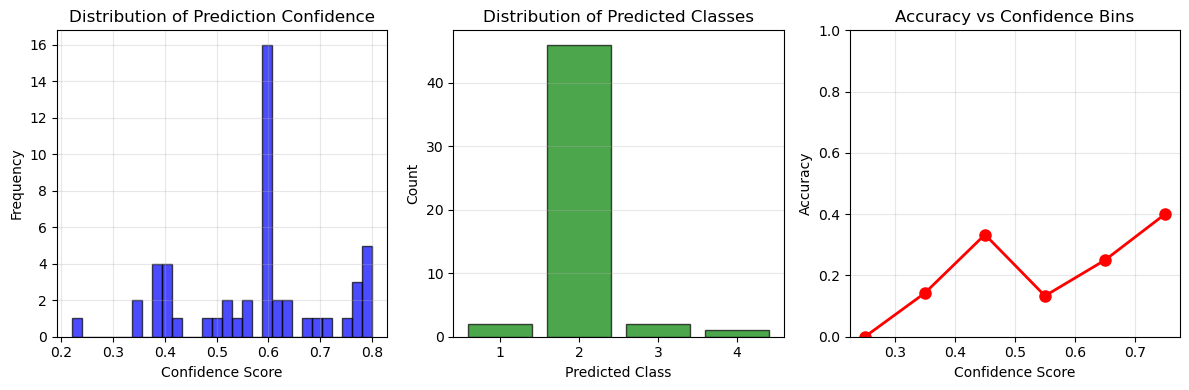


✓ Prediction analysis plots saved!


In [ ]:
if test_features is not None and len(model_paths) > 0:
    # Example: Predict on test data (simulating unknown dataset)
    print("Predicting on test data (as example of unknown dataset)...\n")
    
    # Create example unknown data
    unknown_df = test_df[feature_cols].copy()
    unknown_df['true_label'] = test_labels
    
    # Make predictions
    predictions_df, preds, probs, conf = predict_on_new_data(
        unknown_df, model_paths, feature_cols, scaler=None, ensemble_type='mean'
    )
    
    print("Sample Predictions (first 10 samples):")
    print("-" * 100)
    display_cols = ['true_label', 'predicted_class', 'confidence'] + [f'prob_class_{i}' for i in range(5)]
    print(predictions_df[display_cols].head(10).to_string())
    
    # Save predictions
    predictions_path = os.path.join(result_dir, 'ensemble_predictions.csv')
    predictions_df.to_csv(predictions_path, index=False)
    print(f"\n✓ Predictions saved to {predictions_path}")
    
    # Visualization: Confidence distribution
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.hist(conf, bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Prediction Confidence')
    plt.grid(True, alpha=0.3)
    
    # Prediction distribution
    plt.subplot(1, 3, 2)
    unique, counts = np.unique(preds, return_counts=True)
    plt.bar(unique, counts, color='green', alpha=0.7, edgecolor='black')
    plt.xlabel('Predicted Class')
    plt.ylabel('Count')
    plt.title('Distribution of Predicted Classes')
    plt.xticks(unique)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Accuracy per confidence bin
    plt.subplot(1, 3, 3)
    conf_bins = np.linspace(0, 1, 11)
    accuracies = []
    bin_centers = []
    for i in range(len(conf_bins)-1):
        mask = (conf >= conf_bins[i]) & (conf < conf_bins[i+1])
        if mask.sum() > 0:
            acc = (preds[mask] == test_labels[mask]).mean()
            accuracies.append(acc)
            bin_centers.append((conf_bins[i] + conf_bins[i+1]) / 2)
    
    if accuracies:
        plt.plot(bin_centers, accuracies, 'o-', color='red', linewidth=2, markersize=8)
        plt.xlabel('Confidence Score')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Confidence Bins')
        plt.ylim([0, 1])
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, 'prediction_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Prediction analysis plots saved!")

## Section 6: How to Use Prediction Function on Your Own Data

Create a CSV file with your genomic features in the same format as the training data, then use the prediction function below.

In [ ]:
# EXAMPLE CODE: How to predict on your own CSV data
# Step 1: Load your CSV file with genomic features
new_data_path = 'result/ensemble_predictions.csv'  # Replace with your own CSV path
new_data = pd.read_csv(new_data_path)

# Step 2: Make sure your CSV has the same feature columns as training
# You can check the feature columns from the training data:
print("Expected feature columns:", feature_cols)
print("Number of features expected:", len(feature_cols))

# Step 3: Call the prediction function
predictions = predict_on_new_data(
    new_data, 
    model_paths=model_paths,
    feature_cols=feature_cols,
    scaler=None,  # Use scaler if you applied scaling during training
    ensemble_type='mean'  # or 'majority' for majority voting
)

# Step 4: Save predictions
predictions.to_csv('predictions_on_new_data.csv', index=False)
print("Predictions saved!")

# Step 5: Access prediction results
print("Predicted classes:", predictions['predicted_class'].values)
print("Confidence scores:", predictions['confidence'].values)
print("Probability for each class:")
for i in range(5):
    print(f"  Class {i}: {predictions[f'prob_class_{i}'].values}")

print("✓ Example code ready. Uncomment to use with your own data.")

Expected feature columns: ['A2M', 'AAAS', 'AADAT', 'AARS1', 'ABAT', 'ABCA1', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA8', 'ABCA9', 'ABCB1', 'ABCB11', 'ABCB4', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC1', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCC8', 'ABCD1', 'ABCD2', 'ABCD3', 'ABCE1', 'ABCF2', 'ABCG2', 'ABCG4', 'ABCG8', 'ABHD2', 'ABHD4', 'ABHD6', 'ABI1', 'ABI3BP', 'ABL1', 'ABLIM1', 'ABR', 'ACAA1', 'ACAA2', 'ACACA', 'ACADL', 'ACADM', 'ACADS', 'ACADSB', 'ACADVL', 'ACAT1', 'ACAT2', 'ACE', 'ACHE', 'ACKR1', 'ACKR3', 'ACLY', 'ACO2', 'ACOT2', 'ACOT8', 'ACOX1', 'ACOX2', 'ACOX3', 'ACP1', 'ACP2', 'ACP5', 'ACRBP', 'ACRV1', 'ACSL1', 'ACSL3', 'ACSL4', 'ACSL5', 'ACSL6', 'ACSM1', 'ACSM3', 'ACSS1', 'ACSS2', 'ACTA1', 'ACTA2', 'ACTB', 'ACTC1', 'ACTG1', 'ACTG2', 'ACTL7B', 'ACTN1', 'ACTN2', 'ACTN3', 'ACTN4', 'ACTR2', 'ACTR3', 'ACVR1', 'ACVR1B', 'ACVR2A', 'ACVRL1', 'ADA', 'ADAD1', 'ADAM10', 'ADAM12', 'ADAM15', 'ADAM17', 'ADAM19', 'ADAM2', 'ADAM23', 'ADAM8', 'ADAM9', 'ADAMDEC1', 'ADAMTS1', 'ADAMTS5'

AttributeError: 'tuple' object has no attribute 'to_csv'

## Summary and Key Improvements

### Fixes Applied to Improve Model Stability:

1. **Fixed Data Loading Issues** ✓
   - Now uses ALL test data for validation (not just 10%)
   - Proper data shuffling for training

2. **Added Regularization** ✓
   - Batch Normalization layers added to model architecture
   - L2 weight decay in optimizer (default: 1e-4)
   - Gradient clipping to prevent exploding gradients
   - Dropout layers for additional regularization

3. **Early Stopping** ✓
   - Monitors validation loss with patience of 15 epochs
   - Automatically saves best model checkpoint
   - Prevents overfitting by stopping when validation loss plateaus

4. **Model Checkpointing** ✓
   - Best model saved for each fold
   - Models stored in `result/model_checkpoints/`

5. **Improved Evaluation** ✓
   - Confusion matrix visualization
   - Per-class precision, recall, F1-score
   - Overall accuracy metrics
   - Confidence distribution analysis

### Files Generated:
- `result/model_checkpoints/best_model_fold_{0-4}.pt` - Trained models
- `result/confusion_matrix.png` - Confusion matrix visualization
- `result/training_history_all_folds.png` - Training curves
- `result/prediction_analysis.png` - Prediction confidence analysis
- `result/ensemble_predictions.csv` - Full predictions with probabilities

### How to Use for Your Own Data:
See Section 6 above for complete example code.